## **🔄️ ReAct Loop in LangGraph**

### **What We're Doing & Why**

You already built FinBot using `create_agent`. It works. So why change it?

```python
# What you had — clean, but a black box
my_finance_agent = create_agent(
    model=llm,
    tools=tools,
    system_prompt=SYSTEM_PROMPT
)
```

`create_agent` hides the entire ReAct loop inside itself. You can't:
- Add a step **before** the loop (e.g. sanitise the ticker)
- Add a step **after** the loop (e.g. extract and format the final report cleanly)
- See which tool was called and why at each iteration
- Persist conversation memory across turns
- Stream progress node-by-node to a UI
LangGraph solves all of this by making the loop **explicit**. Here's the graph we're going to build:

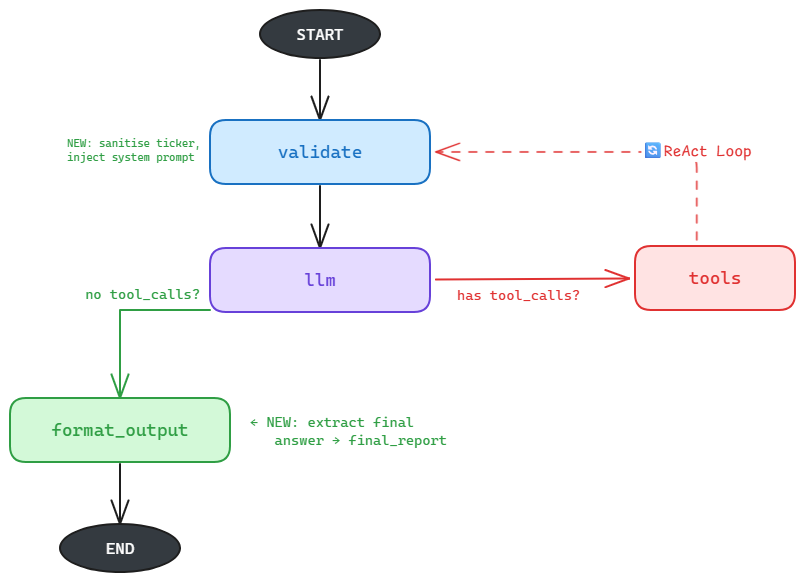

Every box is a Python function you wrote. Every arrow is an edge you defined. Nothing is hidden.

In [1]:
!pip install -q langgraph langchain langchain-core langchain-community langchain-groq pydantic yfinance google-search-results wikipedia python-dotenv

In [2]:
import os
from typing import Annotated, Literal, TypedDict

# LangChain
from langchain_core.messages import (
    AIMessage,
    BaseMessage,
    HumanMessage,
    SystemMessage,
)
from langchain_groq import ChatGroq

# LangGraph
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import END, START, StateGraph
from langgraph.graph.message import add_messages   # reducer: appends, never overwrites
from langgraph.prebuilt import ToolNode

# Tool dependencies
import yfinance as yf
from langchain.tools import tool
from langchain_community.tools import WikipediaQueryRun
from langchain_community.tools.yahoo_finance_news import YahooFinanceNewsTool
from langchain_community.utilities import SerpAPIWrapper, WikipediaAPIWrapper

/tmp/ipykernel_3188/735004899.py:22: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import WikipediaQueryRun


💡 **Nothing changes here.** `ToolNode` (the LangGraph way to run tools) accepts the exact same `@tool`-decorated functions and `BaseTool` instances that `AgentExecutor` did. Your tools are already portable.

### **SerpAPI**

Allows us to query through google search.

**How to access the API KEY?**

1. Go to https://serpapi.com/dashboard
2. Login with email or Google
3. Get access to the dashboad and click on `API Key`
4. Copy it somewhere safe
5. Paste it in the text box

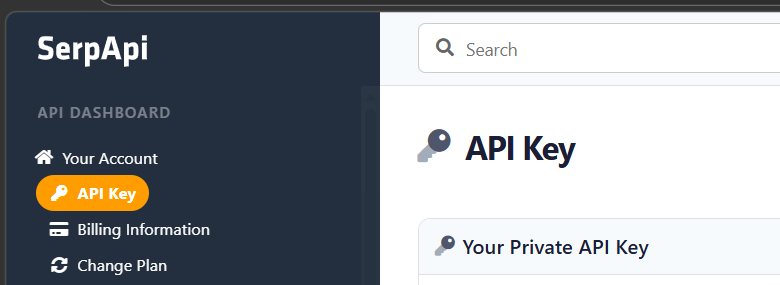

In [4]:
import os
import getpass

if "SERPAPI_API_KEY" not in os.environ:
    os.environ["SERPAPI_API_KEY"] = getpass.getpass("Enter your SerpAPI API key: ")

Enter your SerpAPI API key: ··········


In [5]:
# ── Tool 1: Stock Fundamentals ─────────────────────────────────────────────

@tool
def get_stock_fundamentals(ticker: str) -> dict:
    """Get current stock price, P/E ratio, market cap, and revenue growth for a ticker."""
    stock = yf.Ticker(ticker)
    info  = stock.info
    return {
        "price":          info.get("currentPrice"),
        "pe_ratio":       info.get("trailingPE"),
        "market_cap":     info.get("marketCap"),
        "revenue_growth": info.get("revenueGrowth"),
        "52w_high":       info.get("fiftyTwoWeekHigh"),
        "52w_low":        info.get("fiftyTwoWeekLow"),
    }


# ── Tool 2: Google News (SerpAPI) ──────────────────────────────────────────

serp = SerpAPIWrapper(
    serpapi_api_key=os.getenv("SERPAPI_API_KEY"),
    params={
        "tbm": "nws",    # Google News tab
        "tbs": "qdr:d",  # Past 24 hours only
    },
)

@tool
def search_news(query: str) -> str:
    """Search last-24h Google News via SerpAPI. Returns results with URLs."""
    return serp.run(query)


# ── Tool 3 & 4: Yahoo Finance News + Wikipedia ─────────────────────────────

tools = [
    get_stock_fundamentals,
    YahooFinanceNewsTool(),
    WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper()),
    search_news,
]

print(f"✅ {len(tools)} tools registered:")
for t in tools:
    print(f"   • {t.name}")

✅ 4 tools registered:
   • get_stock_fundamentals
   • yahoo_finance_news
   • wikipedia
   • search_news


## Setting up Groq for LLM Inference

**💡What is Groq?**

A platform that serves LLMs and provides access to OpenSource models in their freetier

---

**💡How to access models on Groq?**
 1. Visit : https://console.groq.com/keys
 2. Create an account using your email ID
 3. Click on the "Create API Key" button and enter a name for the key (we are using "CB_LangChain"
 4. Copy the generated key and paste it some where save
 5. Run the code below and paste the groq API Key in the text box

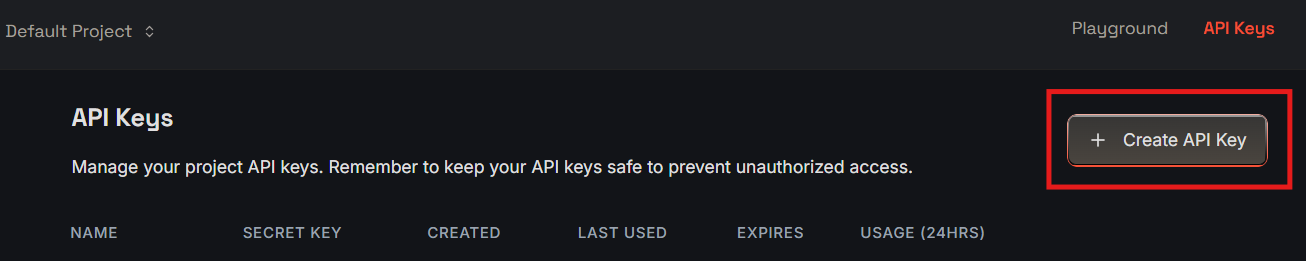

In [6]:
import getpass
import os

if "GROQ_API_KEY" not in os.environ:
    os.environ["GROQ_API_KEY"] = getpass.getpass("Enter your Groq API key: ")

Enter your Groq API key: ··········


In [7]:
from langchain_core.messages import SystemMessage

from langchain_groq import ChatGroq

llm = ChatGroq(
    model="qwen/qwen3-32b",
    temperature=0,
    max_tokens=None,
    reasoning_format="parsed",
    timeout=None,
    max_retries=2,
)

Bind tools — this is what create_agent was doing internally, now made explicit.

It attaches tool schemas to every LLM request so the model knows what's available.

In [8]:
llm_with_tools = llm.bind_tools(tools)

print("✅ LLM ready:", llm.model_name)
print(f"✅ Tools bound: {[t.name for t in tools]}")

✅ LLM ready: qwen/qwen3-32b
✅ Tools bound: ['get_stock_fundamentals', 'yahoo_finance_news', 'wikipedia', 'search_news']


In [9]:
SYSTEM_PROMPT = """
You are FinBot, an expert equity research analyst with deep knowledge of financial markets,
valuation methodologies, and macroeconomic trends.

## Task
Given a stock ticker or company name, produce a concise, structured analyst brief that helps
users evaluate the investment. Do not give buy/sell advice. Present data-driven signals only.

## Rules
1. Gather data before analysis. Never rely on memory for numbers.
2. If a tool fails or returns empty data, state it and proceed.
3. Never fabricate prices, ratios, or news.
4. Always follow the output format below once you have all data.
5. Flag notable risks or red flags.

## Output Format

**[TICKER] — Analyst Brief**
- 📊 **Fundamentals:** price, P/E, market cap, revenue growth (one line)
- 📈 **Valuation Signal:** OVERVALUED / FAIRLY VALUED / UNDERVALUED + reason
- 📰 **News Sentiment:** bullish / neutral / bearish + key headline
- ⚠️ **Key Risks:** 1–2 bullets
- 🧭 **Outlook:** 1–2 sentence synthesis, no advice
"""

print("✅ System prompt defined")

✅ System prompt defined


In [10]:
class FinBotState(TypedDict):
    ticker:       str                                          # Sanitised ticker (e.g. "NVDA")
    messages:     Annotated[list[BaseMessage], add_messages]   # Full message history (appended, not overwritten)
    final_report: str                                          # Clean final output for the caller

print("✅ FinBotState defined with 3 fields: ticker, messages, final_report")

✅ FinBotState defined with 3 fields: ticker, messages, final_report


In [11]:
def validate_node(state: FinBotState) -> dict:
    """
    Runs ONCE before the ReAct loop.
    - Sanitises the ticker (strip whitespace, uppercase)
    - Injects the SystemMessage (the FinBot persona + rules)
    - Adds the first HumanMessage (the actual analysis request)
    """
    ticker = state["ticker"].strip().upper()
    print(f"🔎 Starting analysis for: {ticker}")

    opening_messages = [
        SystemMessage(content=SYSTEM_PROMPT),
        HumanMessage(content=f"Analyse the stock {ticker} and produce the full analyst brief."),
    ]

    # We return both fields we're updating.
    # add_messages will APPEND opening_messages to state["messages"] (currently []).
    return {
        "ticker":   ticker,
        "messages": opening_messages,
    }

print("✅ validate_node defined")

✅ validate_node defined


In [12]:
def agent_node(state: FinBotState) -> dict:
    """
    The reasoning brain of the ReAct loop.
    Called on every iteration — both the first "what tools do I need?" pass
    and all subsequent "given the tool results, what's next?" passes.
    """
    print(f"\n🤖 Agent thinking... ({len(state['messages'])} messages in context)")

    # The LLM sees the FULL message history: system prompt, human query,
    # previous tool calls, and all tool results accumulated so far.
    response = llm_with_tools.invoke(state["messages"])

    # Log the decision for transparency
    if response.tool_calls:
        for tc in response.tool_calls:
            print(f"   → Calling tool: {tc['name']}({tc['args']})")
    else:
        print("   → No more tool calls. Final answer ready.")

    # Return only the new message. add_messages appends it to the history.
    return {"messages": [response]}

print("✅ agent_node defined")

✅ agent_node defined


In [13]:
# One line — same tools list, no other changes needed
tool_node = ToolNode(tools)

print("✅ tool_node defined (ToolNode with 4 tools)")

✅ tool_node defined (ToolNode with 4 tools)


In [14]:
def format_output_node(state: FinBotState) -> dict:
    """
    Runs ONCE after the ReAct loop finishes.
    Extracts the agent's last plain-text AIMessage and stores it in final_report.
    """
    final_answer = ""

    # Walk backwards — the last AIMessage without tool_calls is the final answer
    for message in reversed(state["messages"]):
        is_ai_message    = isinstance(message, AIMessage)
        has_no_tool_call = not getattr(message, "tool_calls", None)
        if is_ai_message and has_no_tool_call:
            final_answer = message.content
            break

    print("\n📋 Final report extracted → stored in state['final_report']")
    return {"final_report": final_answer}

print("✅ format_output_node defined")

✅ format_output_node defined


In [15]:
def should_continue(state: FinBotState) -> Literal["tools", "format_output"]:
    """
    Called after every agent_node execution.
    Inspects the last message and decides the next step:

      AIMessage WITH tool_calls   →  "tools"          (keep looping)
      AIMessage WITHOUT tool_calls →  "format_output"  (exit loop, clean up)
    """
    last_message = state["messages"][-1]

    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        return "tools"           # → execute tools, then back to agent
    return "format_output"       # → extract final answer, then END

print("✅ should_continue router defined")

✅ should_continue router defined


In [16]:
builder = StateGraph(FinBotState)

# ── Register nodes ────────────────────────────────────────────────────────────
builder.add_node("validate",      validate_node)      # Node A — runs once, pre-loop
builder.add_node("agent",         agent_node)         # Node B — the ReAct brain
builder.add_node("tools",         tool_node)          # Node C — tool executor
builder.add_node("format_output", format_output_node) # Node D — runs once, post-loop

# ── Wire edges ────────────────────────────────────────────────────────────────
builder.add_edge(START,      "validate")  # Entry point
builder.add_edge("validate", "agent")     # After validation, start the loop

builder.add_conditional_edges(            # The branching heart of the ReAct loop
    "agent",                              #   source: after agent runs...
    should_continue,                      #   ...call router to decide next node
    {
        "tools":         "tools",         #   if router returns "tools"         → tool_node
        "format_output": "format_output", #   if router returns "format_output" → format_output_node
    }
)

builder.add_edge("tools",         "agent")  # After tools run, always loop back to agent
builder.add_edge("format_output", END)      # After formatting, we're done

# ── Compile ───────────────────────────────────────────────────────────────────
# MemorySaver gives the graph persistent memory across turns.
# Each unique thread_id gets its own isolated conversation history.
# Remove checkpointer= for a stateless (single-turn) agent.

memory = MemorySaver()
finbot = builder.compile(checkpointer=memory)

print("✅ FinBot graph compiled successfully")

✅ FinBot graph compiled successfully


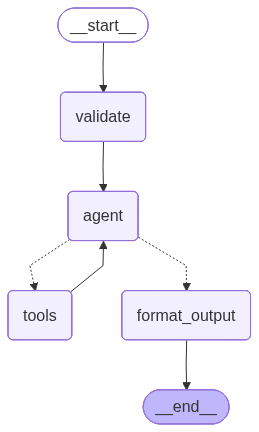

In [17]:
from IPython.display import Image, display

display(Image(finbot.get_graph().draw_mermaid_png()))

In [18]:
def analyse(ticker: str, thread_id: str = "default") -> str:
    """
    Run FinBot and return the analyst brief.

    Args:
        ticker    : Stock ticker (e.g. "AAPL", "TSLA", "NVDA")
        thread_id : Reuse the same ID to continue a conversation;
                    use a new ID for a fresh session.
    Returns:
        The formatted analyst brief as a plain string.
    """
    config = {"configurable": {"thread_id": thread_id}}

    initial_state: FinBotState = {
        "ticker":       ticker,
        "messages":     [],    # validate_node populates this
        "final_report": "",
    }

    print(f"\n{'='*60}")
    print(f"  FinBot — Analysing: {ticker.strip().upper()}")
    print(f"{'='*60}")

    result = finbot.invoke(initial_state, config=config)

    print(f"\n{'='*60}")
    print(result["final_report"])
    print(f"{'='*60}\n")

    return result["final_report"]

In [19]:
report = analyse("NVDA")


  FinBot — Analysing: NVDA
🔎 Starting analysis for: NVDA

🤖 Agent thinking... (2 messages in context)
   → Calling tool: get_stock_fundamentals({'ticker': 'NVDA'})
   → Calling tool: yahoo_finance_news({'query': 'NVDA'})
   → Calling tool: search_news({'query': 'NVIDIA stock analysis site:finance.yahoo.com'})

🤖 Agent thinking... (6 messages in context)
   → No more tool calls. Final answer ready.

📋 Final report extracted → stored in state['final_report']

**NVDA — Analyst Brief**  
- 📊 **Fundamentals:** $205.19, P/E 31.42, Market Cap $4.97T, Revenue Growth 85.2%  
- 📈 **Valuation Signal:** **FAIRLY VALUED** — High revenue growth offsets elevated P/E; aligns with AI-driven demand.  
- 📰 **News Sentiment:** **BULLISH** — Strategic partnerships (e.g., Lumentum, CoreWeave) and AI data center expansion highlight growth potential.  
- ⚠️ **Key Risks:**  
  - Elevated P/E (31.42) may underperform if growth slows.  
  - Intense competition in AI hardware (AMD, Intel).  
- 🧭 **Outlook:** NVI